In [15]:
import numpy as np
import pandas as pd


In [16]:
df=pd.read_csv('customer_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
print(df.info())
print(df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

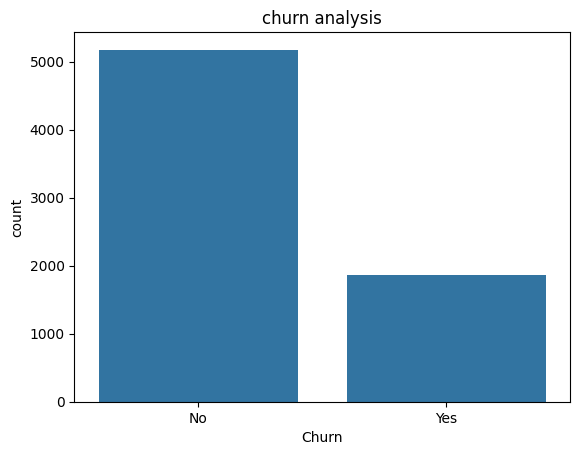

In [20]:
df['Churn'].value_counts()
sns.countplot(x='Churn',data=df)
plt.title('churn analysis')
plt.show()

In [21]:
# Identify categorical and numerical features
categorical_features=df.select_dtypes(include='object').columns.tolist()
numerical_features=df.select_dtypes(include=['int64','float64']).columns.tolist()

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    if 'customerID' in categorical_features:
        categorical_features.remove('customerID')
    print("\n'customerID' column removed.")
else:
    print("\n'customerID' column not found.")


print('categorical_features:',categorical_features)
print('numerical_features:',numerical_features)


'customerID' column removed.
categorical_features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
numerical_features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [22]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
label_encoder=LabelEncoder()
for col in ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling',
            'PaymentMethod', 'Churn', 'gender']:
    if col in df.columns:
        df[col]=label_encoder.fit_transform(df[col])
# One hot encode 
df = pd.get_dummies(df, columns=[col for col in categorical_features if col not in ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling',
            'PaymentMethod', 'Churn', 'gender']], drop_first=True)

print("\nProcessed dataset information after encoding:")
df.info()


Processed dataset information after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6549 entries, gender to TotalCharges_999.9
dtypes: bool(6530), float64(1), int64(18)
memory usage: 44.9 MB


In [23]:
# standard scalar
numerical_features=[col for col in numerical_features if col!='Churn']
scalar=StandardScaler()
df[numerical_features] = scalar.fit_transform(df[numerical_features])
print("\nProcessed dataset information after scaling:")
df.info()
print("\nFirst 5 rows of the scaled data:")
print(df.head())


Processed dataset information after scaling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6549 entries, gender to TotalCharges_999.9
dtypes: bool(6530), float64(3), int64(16)
memory usage: 44.9 MB

First 5 rows of the scaled data:
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0      -0.439916        1           0 -1.277445             0   
1       1      -0.439916        0           0  0.066327             1   
2       1      -0.439916        0           0 -1.236724             1   
3       1      -0.439916        0           0  0.514251             0   
4       0      -0.439916        0           0 -1.236724             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0              1                0               0             2  ...   
1              0                0               2             0  ...   
2              0                0               2             2  ...   
3  

In [24]:
bins = [0, 12, 24, 36, 48, 60, np.inf]
labels = ['0-12 Months', '13-24 Months', '25-36 Months', '37-48 Months', '49-60 Months', '60+ Months']
if 'tenure' in df.columns:
    df['Tenure_Group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)
    df = pd.get_dummies(df, columns=['Tenure_Group'], drop_first=True)
    print("\n'Tenure_Group' feature created and one-hot encoded.")
else:
    print("\n'tenure' column not found, skipping 'Tenure_Group' feature engineering.")

print("\nDataset information after optional feature engineering:")
df.info()
print("\nFirst 5 rows after optional feature engineering:")
print(df.head())


'Tenure_Group' feature created and one-hot encoded.

Dataset information after optional feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 6554 entries, gender to Tenure_Group_60+ Months
dtypes: bool(6535), float64(3), int64(16)
memory usage: 44.9 MB

First 5 rows after optional feature engineering:
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0      -0.439916        1           0 -1.277445             0   
1       1      -0.439916        0           0  0.066327             1   
2       1      -0.439916        0           0 -1.236724             1   
3       1      -0.439916        0           0  0.514251             0   
4       0      -0.439916        0           0 -1.236724             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0              1                0               0             2  ...   
1              0                0               2             

In [25]:
# Train and Test Split
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [26]:
# Train XGBoost Model
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:,1]

print("AUC-ROC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

AUC-ROC: 0.832055852644088
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [27]:
import joblib

# Train your model
xgb.fit(X_train, y_train)

# Save the trained model
joblib.dump(xgb, "xgb_churn_model.pkl")


['xgb_churn_model.pkl']

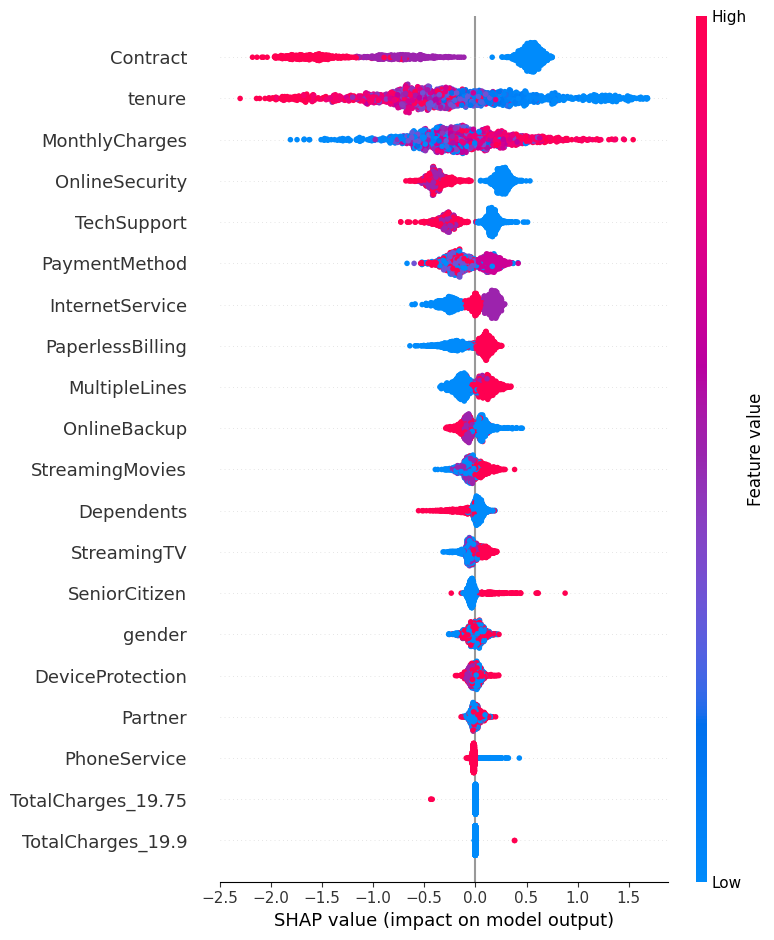

In [28]:
# Explain with SHAP

import shap
shap.initjs()


explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test)

# Local explanation for one customer
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])